In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [24]:
azure_endpoint = os.environ.get('AZURE_OPENAI_ENDPOINT')
azure_api_key = os.environ.get('AZURE_OPENAI_API_KEY')

model = ChatOpenAI(
    model="gpt-5-mini",
    base_url=azure_endpoint,
    api_key=azure_api_key
)

In [25]:
class ReviewState(TypedDict):
    review: str
    sentiment: str
    issue_type: str
    tone: str
    urgency: str
    reply: str

class FinalReply(BaseModel):
    reply: str = Field(description="Final reply to the customer's review in format of a email")

class SentimentAnalysis(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review whether it's positive or negative")

class Diagnosis(BaseModel):
    issue_type: str = Field(description='the issue related type of the review in one word like hardware, bug, heating etc.')
    tone: str = Field(description="Tone of the review in one word like frustrated, angry etc.")
    urgency: str = Field(description="Level of urgency in one word like high, low, medium")

final_reply_output = model.with_structured_output(FinalReply)
sentiment_output = model.with_structured_output(SentimentAnalysis)
diagnosis_output = model.with_structured_output(Diagnosis)


In [26]:
graph = StateGraph(ReviewState)

In [27]:
def eval_review(state: ReviewState):
    prompt = f"Calculate the sentiment of following review: \n {state['review']}"
    sentiment = sentiment_output.invoke(prompt)
    return { 'sentiment': sentiment.sentiment }

In [28]:
def gen_positive_reply(state: ReviewState):
    prompt = f"Generate a reply to the following positive review: {state['review']}"
    reply = final_reply_output.invoke(prompt)
    return {'reply': reply.reply}


In [29]:
def run_diagnosis(state: ReviewState):
    prompt = f"Extract out the information of issue type, tone and urgency from the following negative reply: \n {state['review']}"
    result = diagnosis_output.invoke(prompt)
    return {
        'issue_type': result.issue_type,
        'tone': result.tone,
        'urgency': result.urgency
    }

In [30]:
def route_sentiment(state: ReviewState):
    if state['sentiment'] == 'positive':
        return "reply_for_pos"
    elif state['sentiment'] == 'negative':
        return "run_diagnosis"

In [31]:
def gen_negative_reply(state: ReviewState):
    prompt = f"""
Here are some important details about the review:
issue_type: {state['issue_type']}
urgency: {state['urgency']},
tone: {state['tone']}

Generate a reply to the following review based on the above information:\n{state['review']}
"""
    reply = final_reply_output.invoke(prompt)
    return {
        'reply': reply.reply
    }

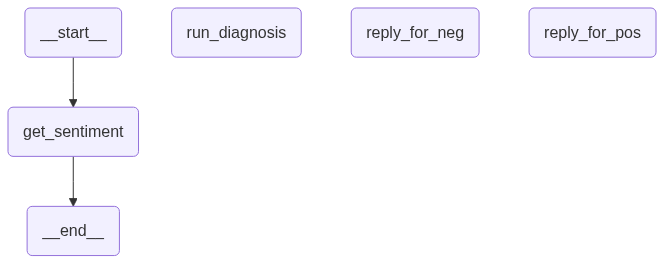

In [32]:
graph.add_node('get_sentiment', eval_review)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('reply_for_neg', gen_negative_reply)
graph.add_node('reply_for_pos', gen_positive_reply)

graph.add_edge(START, 'get_sentiment'),
graph.add_conditional_edges('get_sentiment', route_sentiment)
graph.add_edge('run_diagnosis', 'reply_for_neg')
graph.add_edge('reply_for_neg', END)
graph.add_edge('reply_for_pos', END)
workflow = graph.compile()

workflow

In [22]:
review = """I’m extremely frustrated with this phone and honestly regret buying it. The performance has become unreliable, with apps freezing, random crashes, and noticeable lag even during basic tasks. The battery drains far too quickly, and the phone gets unusually hot with normal use. What’s even worse is that these problems keep happening despite restarting the device and installing the latest updates. This is not something I expected from a smartphone at this price. The manufacturer needs to address these issues urgently with a proper software update or replacement. I need a reliable phone for everyday use, and right now, this device is causing more problems than it solves."""

initial_state: ReviewState = {
    "review": review
}

workflow.invoke(initial_state)

{'review': 'I’m extremely frustrated with this phone and honestly regret buying it. The performance has become unreliable, with apps freezing, random crashes, and noticeable lag even during basic tasks. The battery drains far too quickly, and the phone gets unusually hot with normal use. What’s even worse is that these problems keep happening despite restarting the device and installing the latest updates. This is not something I expected from a smartphone at this price. The manufacturer needs to address these issues urgently with a proper software update or replacement. I need a reliable phone for everyday use, and right now, this device is causing more problems than it solves.',
 'sentiment': 'negative',
 'issue_type': 'performance',
 'tone': 'frustrated',
 'urgency': 'high',
 'reply': 'Hello,\n\nI’m very sorry to hear how much this has disrupted your daily use — I completely understand your frustration and regret that this device is falling short of what you reasonably expect. Perfo